# Heart Disease Prediction
### Super AI Engineer Season 6 – Hackathon 5
**Metric: F2-Score** (higher recall weight – critical in healthcare)

---
Pipeline:
1. Load & explore data (EDA)
2. Preprocessing & encoding
3. Class imbalance handling (SMOTE)
4. Model training & cross-validation
5. Threshold tuning for F2-score
6. Generate submission

## Step 1: Import Libraries

Import all required libraries for this pipeline:
- **`pandas` / `numpy`** — data loading, manipulation, and numerical operations
- **`matplotlib` / `seaborn`** — visualization for EDA and evaluation plots
- **`sklearn`** — preprocessing (encoding, scaling), model training, cross-validation, and metrics
- **`imblearn.SMOTE`** — Synthetic Minority Over-sampling Technique for handling class imbalance

`warnings.filterwarnings('ignore')` suppresses non-critical warnings to keep output clean.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import fbeta_score, make_scorer, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')
print("Libraries loaded successfully")

Libraries loaded successfully


## Step 2: Load Data & Inspect Class Balance

Load the training set, test set, and sample submission CSV from disk.

Key insights from this cell:
- **Train/Test shapes** — how many rows and features are available
- **Target distribution** — counts of `Yes` (has heart disease) vs `No` (healthy)
- **Positive rate** — the fraction of positive cases; a low rate confirms **class imbalance**, which requires special handling (SMOTE or `class_weight='balanced'`)

The target column is: `History of HeartDisease or Attack`


In [2]:
import os

DATA_PATH = r"C:\Users\punda\Desktop\superAI\Hackathon 5\Heart Disease Prediction\super-ai-engineer-ss-6-heart-disease-prediction"

train = pd.read_csv(os.path.join(DATA_PATH, 'train.csv'))
test  = pd.read_csv(os.path.join(DATA_PATH, 'test.csv'))
sample_sub = pd.read_csv(os.path.join(DATA_PATH, 'sample_submission.csv'))

TARGET = 'History of HeartDisease or Attack'

print(f"Train shape : {train.shape}")
print(f"Test shape  : {test.shape}")
print(f"\nTarget distribution:\n{train[TARGET].value_counts()}")
print(f"\nPositive rate: {train[TARGET].eq('Yes').mean():.4f}")
train.head()

Train shape : (223084, 20)
Test shape  : (74361, 19)

Target distribution:
History of HeartDisease or Attack
No     203322
Yes     18068
Name: count, dtype: int64

Positive rate: 0.0810


,ID,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,Doctor Visit Cost Barrier,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day)
0,train_000001,No,Yes,Yes,Yes,40.68,Yes,No,No,No,No,Yes,No,Very Poor,Yes,Female,High school graduate,"$15,000 to less than $20,000",64,Yes
1,train_000002,No,No,No,No,24.36,Yes,No,No,Yes,No,No,Yes,Fair,No,Female,College graduate,"Less than $10,000",50,No
2,train_000003,No,Yes,Yes,Yes,27.33,No,No,No,No,No,Yes,Yes,Very Poor,Yes,Female,High school graduate,"$75,000 or more",61,Yes
3,train_000004,No,Yes,No,Yes,27.01,No,No,No,Yes,No,Yes,No,Good,No,Female,Some high school,"$35,000 to less than $50,000",74,Yes
4,train_000005,NaN,Yes,Yes,Yes,34.56,Yes,No,No,Yes,No,Yes,Yes,Very Poor,Yes,Male,Some high school,"$15,000 to less than $20,000",98,Yes


## Step 3: EDA — Missing Values & Descriptive Statistics

Check data quality before modeling:
- **Missing values** — identify which columns have nulls that need imputation; missing values must be handled before training
- **Descriptive statistics** — `describe()` shows mean, std, min, max, and quartiles for all numeric columns, helping spot outliers (e.g., extreme BMI values) or incorrectly encoded data


In [3]:
# ── EDA: Missing values & basic stats ────────────────────────────────────────
print("=== Missing values (train) ===")
print(train.isnull().sum())
print("\n=== Missing values (test) ===")
print(test.isnull().sum())
print("\n=== Numeric summary ===")
train.describe()

=== Missing values (train) ===
ID                                            0
History of HeartDisease or Attack          1694
High Blood Pressure                           0
Told High Cholesterol                     32186
Cholesterol Checked                           0
Body Mass Index                           11782
Smoked 100+ Cigarettes                        1
Diagnosed Stroke                              0
Diagnosed Diabetes                            3
Leisure Physical Activity                     0
Heavy Alcohol Consumption                     0
Health Care Coverage                          0
Doctor Visit Cost Barrier                     1
General Health                                1
Difficulty Walking                            3
Sex                                           0
Education Level                               0
Income Level                                  0
Age                                           0
Vegetable or Fruit Intake (1+ per Day)        0
dtype: in

,Body Mass Index,Age
count,211302.000000,223084.000000
mean,28.189817,54.739717
std,6.688447,17.795140
min,11.210000,18.000000
25%,23.880000,42.000000
50%,27.070000,56.000000
75%,31.100000,67.000000
max,98.630000,100.000000


## Step 4: EDA — Target Class Distribution

Visualize the class balance with two plots:
- **Count bar chart** — shows the absolute number of `Yes` and `No` cases with percentages annotated
- **Pie chart** — shows proportional split at a glance

A heavily imbalanced dataset (e.g., only 10–15% positive) means a naive classifier predicting "No" every time would achieve high accuracy but terrible recall — exactly why **F2-score** is used as the metric, which penalizes missing actual positive cases (false negatives) more heavily.


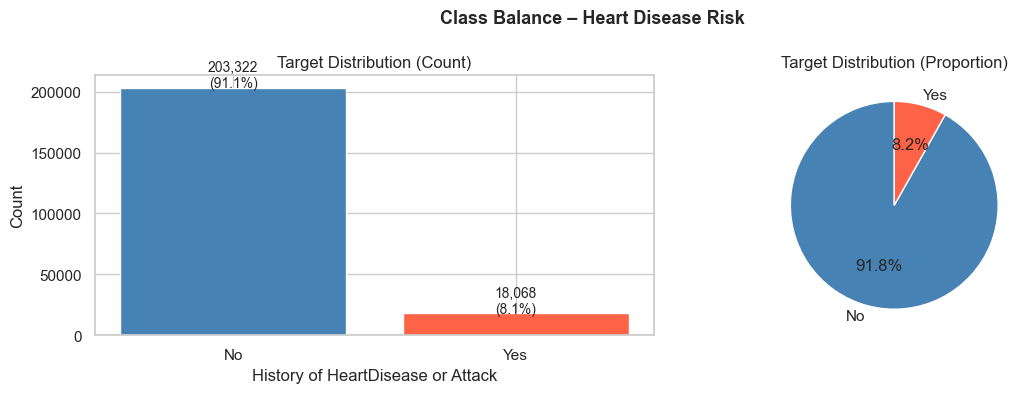

In [4]:
# ── EDA: Target distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
target_counts = train[TARGET].value_counts()
axes[0].bar(target_counts.index, target_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Target Distribution (Count)')
axes[0].set_xlabel('History of HeartDisease or Attack')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 300, f'{v:,}\n({v/len(train)*100:.1f}%)', ha='center', fontsize=10)

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Target Distribution (Proportion)')

plt.suptitle('Class Balance – Heart Disease Risk', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 5: EDA — Binary Features vs Heart Disease Rate

For each binary Yes/No feature (e.g., High Blood Pressure, Diagnosed Diabetes), plot a grouped bar chart showing the **percentage of people with heart disease within each answer group**.

This reveals which features are the strongest predictors:
- If the `Yes` group has a much higher heart disease rate than the `No` group, the feature is discriminative and useful for the model
- For example, `Diagnosed Stroke` and `High Blood Pressure` are expected to show a strong positive association with heart disease


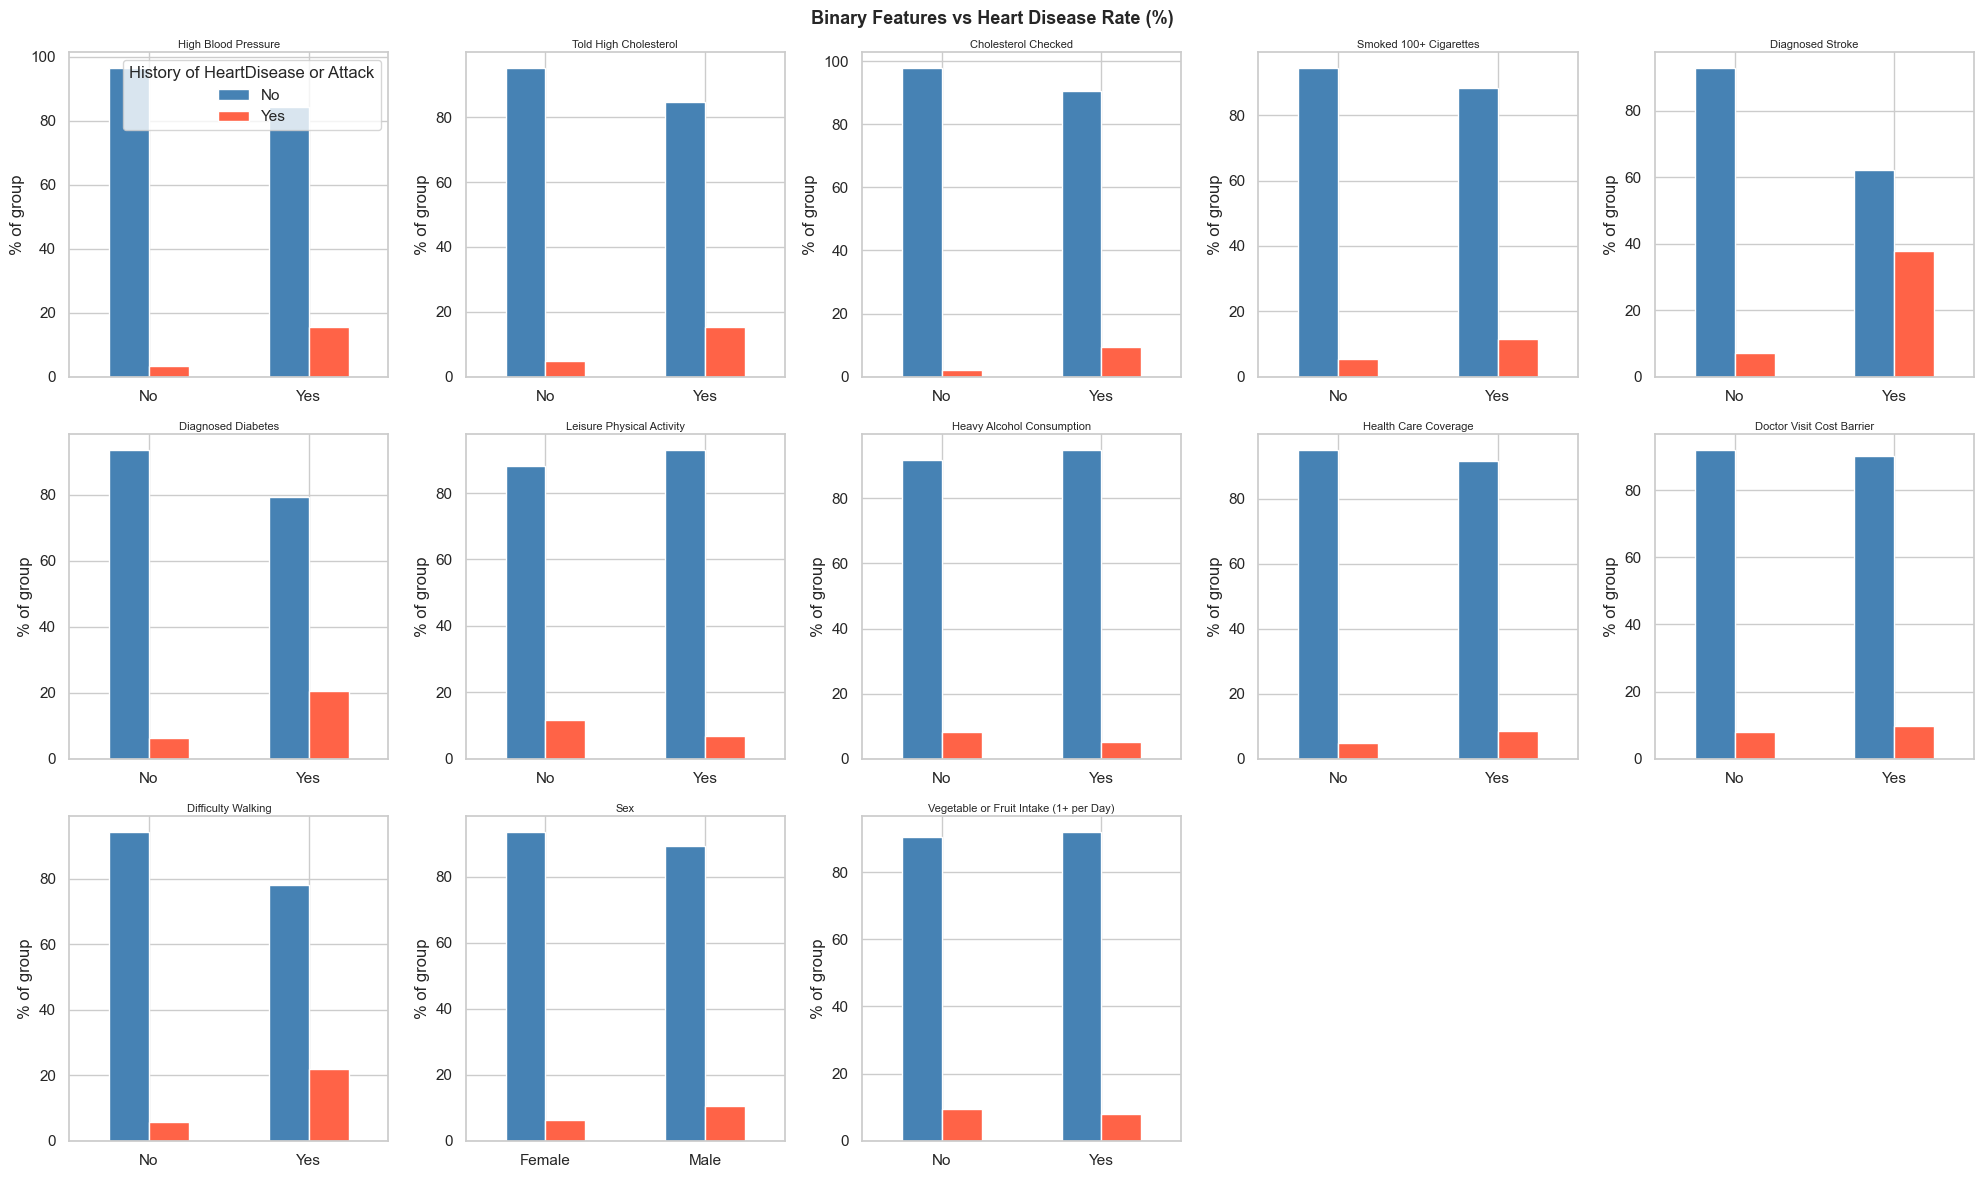

In [5]:
# ── EDA: Binary feature vs Target ────────────────────────────────────────────
binary_cols = [
    'High Blood Pressure', 'Told High Cholesterol', 'Cholesterol Checked',
    'Smoked 100+ Cigarettes', 'Diagnosed Stroke', 'Diagnosed Diabetes',
    'Leisure Physical Activity', 'Heavy Alcohol Consumption', 'Health Care Coverage',
    'Doctor Visit Cost Barrier', 'Difficulty Walking', 'Sex',
    'Vegetable or Fruit Intake (1+ per Day)'
]

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for idx, col in enumerate(binary_cols):
    ct = train.groupby([col, TARGET]).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=axes[idx], color=['steelblue', 'tomato'],
                legend=(idx == 0), rot=0)
    axes[idx].set_title(col, fontsize=8, pad=3)
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('% of group')

for j in range(len(binary_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Binary Features vs Heart Disease Rate (%)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6: EDA — Continuous & Ordinal Features

Visualize the relationship between continuous/ordinal features and the target:

- **BMI histogram** — overlapping distributions for `Yes` vs `No` show whether higher BMI is linked to heart disease risk; a rightward shift for the `Yes` group would confirm it
- **Heart disease rate by Age group** — bar chart showing the percentage of positive cases within each age bracket; older age groups are typically at higher risk
- **General Health vs Target** — people who rate their health as "Poor" or "Very Poor" are likely to have much higher disease rates; this is one of the most predictive ordinal features


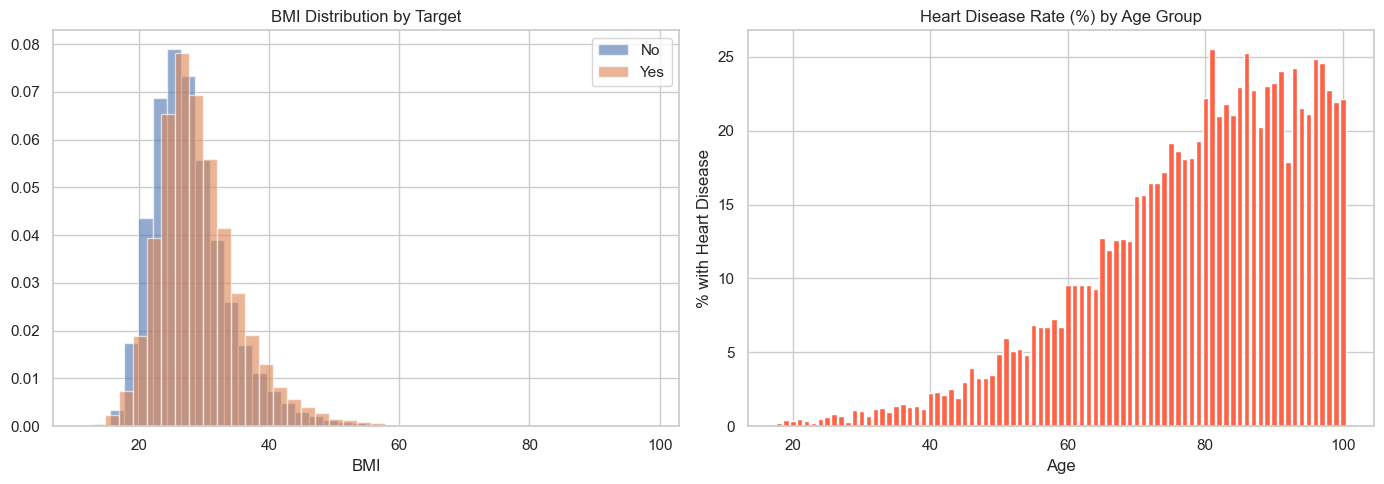

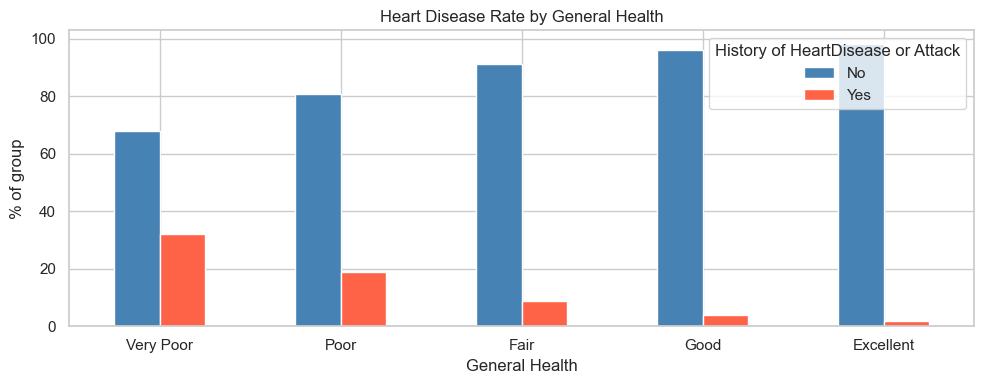

In [6]:
# ── EDA: Continuous & ordinal features ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BMI
for label, grp in train.groupby(TARGET):
    axes[0].hist(grp['Body Mass Index'], bins=40, alpha=0.6, label=label, density=True)
axes[0].set_title('BMI Distribution by Target')
axes[0].set_xlabel('BMI')
axes[0].legend()

# Age
age_order = sorted(train['Age'].unique())
age_heart = train.groupby('Age')[TARGET].apply(lambda x: (x == 'Yes').mean() * 100)
axes[1].bar(age_order, age_heart.reindex(age_order), color='tomato')
axes[1].set_title('Heart Disease Rate (%) by Age Group')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('% with Heart Disease')

plt.tight_layout()
plt.show()

# General Health vs Target
gh_order = ['Very Poor', 'Poor', 'Fair', 'Good', 'Very Good', 'Excellent']
gh_present = [g for g in gh_order if g in train['General Health'].unique()]
ct = train.groupby(['General Health', TARGET]).size().unstack(fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct = ct_pct.reindex([g for g in gh_present if g in ct_pct.index])
ct_pct.plot(kind='bar', color=['steelblue', 'tomato'], figsize=(10, 4), rot=0)
plt.title('Heart Disease Rate by General Health')
plt.ylabel('% of group')
plt.tight_layout()
plt.show()

## Step 7: Preprocessing

The `preprocess()` function converts raw string data into a numeric form suitable for ML models:

| Transformation | Columns | Method |
|----------------|---------|--------|
| Drop identifier | `ID` | Removed (not a feature) |
| Binary encoding | Yes/No columns (13 features) | `Yes → 1`, `No → 0` |
| Binary encoding | `Sex` | `Male → 1`, `Female → 0` |
| Ordinal encoding | `General Health` | `Very Poor=1` … `Excellent=6` |
| Ordinal encoding | `Education Level` | `Never attended=1` … `College=6` |
| Ordinal encoding | `Income Level` | `<$10k=1` … `≥$75k=8` |
| Target encoding | `History of HeartDisease or Attack` | `Yes → 1`, `No → 0` |

**Missing value imputation:** After encoding, any remaining nulls are filled using the **training set median** (robust to outliers) so the test set never leaks future information.


In [7]:
# ── PREPROCESSING ────────────────────────────────────────────────────────────

def preprocess(df, is_train=True):
    df = df.copy()

    # Drop ID
    df = df.drop(columns=['ID'])

    # Separate target for train; drop rows with missing target
    if is_train:
        df = df.dropna(subset=[TARGET])
        y = (df[TARGET] == 'Yes').astype(int)
        df = df.drop(columns=[TARGET])
    else:
        y = None

    # Yes/No -> 1/0 (handle NaN properly)
    yes_no_cols = [
        'High Blood Pressure', 'Told High Cholesterol', 'Cholesterol Checked',
        'Smoked 100+ Cigarettes', 'Diagnosed Stroke', 'Diagnosed Diabetes',
        'Leisure Physical Activity', 'Heavy Alcohol Consumption', 'Health Care Coverage',
        'Doctor Visit Cost Barrier', 'Difficulty Walking',
        'Vegetable or Fruit Intake (1+ per Day)'
    ]
    for col in yes_no_cols:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

    # Sex -> 0/1
    df['Sex'] = df['Sex'].map({'Male': 1, 'Female': 0})

    # General Health -> ordinal
    gh_map = {'Very Poor': 1, 'Poor': 2, 'Fair': 3, 'Good': 4, 'Very Good': 5, 'Excellent': 6}
    df['General Health'] = df['General Health'].map(gh_map)

    # Education Level -> ordinal
    edu_map = {
        'Never attended school or only kindergarten': 1,
        'Elementary': 2,
        'Some high school': 3,
        'High school graduate': 4,
        'Some college or technical school': 5,
        'College graduate': 6
    }
    df['Education Level'] = df['Education Level'].map(edu_map)

    # Income Level -> ordinal
    inc_map = {
        'Less than $10,000': 1,
        '$10,000 to less than $15,000': 2,
        '$15,000 to less than $20,000': 3,
        '$20,000 to less than $25,000': 4,
        '$25,000 to less than $35,000': 5,
        '$35,000 to less than $50,000': 6,
        '$50,000 to less than $75,000': 7,
        '$75,000 or more': 8
    }
    df['Income Level'] = df['Income Level'].map(inc_map)

    return df, y

# Preprocess but keep NaN for now — will fill after combining train info
X_train_raw, y_train = preprocess(train, is_train=True)
X_test_raw, _        = preprocess(test,  is_train=False)

# Fill missing values: use train median/mode for all
train_medians = X_train_raw.median(numeric_only=True)
train_modes   = X_train_raw.mode().iloc[0]  # mode for all columns

X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()

for col in X_train.columns:
    if X_train[col].isnull().any():
        fill_val = train_medians.get(col, train_modes[col])
        X_train[col] = X_train[col].fillna(fill_val)
        X_test[col]  = X_test[col].fillna(fill_val)

print(f"X_train: {X_train.shape}  |  Positive class: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"X_test : {X_test.shape}")
print(f"Remaining NaN in X_train: {X_train.isnull().sum().sum()}")
X_train.head()

X_train: (221390, 18)  |  Positive class: 18068 (8.16%)
X_test : (74361, 18)
Remaining NaN in X_train: 0


,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,Doctor Visit Cost Barrier,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day)
0,1,1.0,1,40.68,1.0,0,0.0,0,0,1,0.0,1.0,1.0,0,4.0,3.0,64,1
1,0,0.0,0,24.36,1.0,0,0.0,1,0,0,1.0,3.0,0.0,0,6.0,1.0,50,0
2,1,1.0,1,27.33,0.0,0,0.0,0,0,1,1.0,1.0,1.0,0,4.0,8.0,61,1
3,1,0.0,1,27.01,0.0,0,0.0,1,0,1,0.0,4.0,0.0,0,3.0,6.0,74,1
5,1,1.0,1,25.11,1.0,0,0.0,1,0,1,0.0,4.0,0.0,1,6.0,8.0,67,1


## Step 8: Feature Engineering

Three new features are created to capture domain-relevant interactions that raw columns may not express individually:

| New Feature | Formula | Interpretation |
|-------------|---------|----------------|
| `risk_count` | Sum of 5 high-risk binary conditions | Patients with multiple comorbidities (hypertension + diabetes + stroke) are at significantly higher compound risk |
| `bmi_cat` | BMI binned into 4 categories (underweight / normal / overweight / obese) | Discretizes BMI so the model can learn non-linear risk thresholds |
| `lifestyle_score` | Sum of unhealthy lifestyle indicators | Combines smoking, heavy drinking, inactivity, and poor diet into a single risk score |

These engineered features help tree-based models (like LightGBM and Random Forest) converge faster and improve prediction on minority-class patients.


In [8]:
# ── FEATURE ENGINEERING ──────────────────────────────────────────────────────
def add_features(df):
    df = df.copy()
    # Interaction: high-risk condition count
    risk_cols = ['High Blood Pressure', 'Told High Cholesterol', 'Diagnosed Stroke',
                 'Diagnosed Diabetes', 'Difficulty Walking']
    df['risk_count'] = df[risk_cols].sum(axis=1)

    # BMI categories: underweight<18.5, normal<25, overweight<30, obese≥30
    df['bmi_cat'] = pd.cut(df['Body Mass Index'],
                           bins=[0, 18.5, 25, 30, 100],
                           labels=[0, 1, 2, 3]).astype(float)

    # Unhealthy lifestyle score
    df['lifestyle_score'] = df['Smoked 100+ Cigarettes'] + df['Heavy Alcohol Consumption'] \
                          + (1 - df['Leisure Physical Activity']) \
                          + (1 - df['Vegetable or Fruit Intake (1+ per Day)'])

    return df

X_train = add_features(X_train)
X_test  = add_features(X_test)

print(f"X_train after feature engineering: {X_train.shape}")
X_train.head()

X_train after feature engineering: (221390, 21)


,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,...,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day),risk_count,bmi_cat,lifestyle_score
0,1,1.0,1,40.68,1.0,0,0.0,0,0,1,...,1.0,1.0,0,4.0,3.0,64,1,3.0,3.0,2.0
1,0,0.0,0,24.36,1.0,0,0.0,1,0,0,...,3.0,0.0,0,6.0,1.0,50,0,0.0,1.0,2.0
2,1,1.0,1,27.33,0.0,0,0.0,0,0,1,...,1.0,1.0,0,4.0,8.0,61,1,3.0,2.0,1.0
3,1,0.0,1,27.01,0.0,0,0.0,1,0,1,...,4.0,0.0,0,3.0,6.0,74,1,1.0,2.0,0.0
5,1,1.0,1,25.11,1.0,0,0.0,1,0,1,...,4.0,0.0,1,6.0,8.0,67,1,2.0,2.0,1.0


## Step 9: Correlation Heatmap — Feature vs Target

Compute the **Pearson correlation** between each feature and the binary target (0/1).

- **Red bars (positive correlation)** — higher values of this feature are associated with higher heart disease risk (e.g., `risk_count`, `High Blood Pressure`)
- **Blue bars (negative correlation)** — higher values are associated with lower risk (e.g., `General Health`, `Leisure Physical Activity`)

This plot validates that the engineered features (`risk_count`, `lifestyle_score`) capture meaningful signal, and confirms which raw features carry the most predictive information.


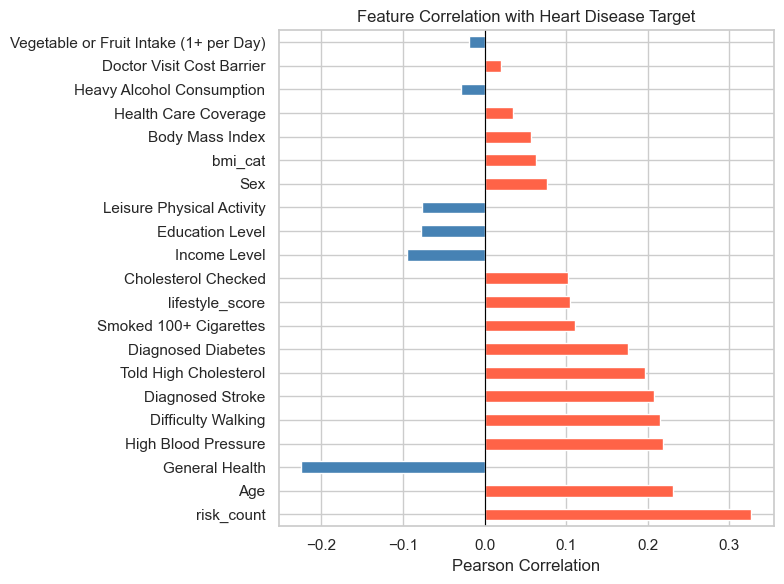

Top positive correlators:
 risk_count               0.327259
Age                      0.231322
General Health          -0.224788
High Blood Pressure      0.218911
Difficulty Walking       0.214661
Diagnosed Stroke         0.208151
Told High Cholesterol    0.196574
Diagnosed Diabetes       0.175597
Name: target, dtype: float64

Top negative correlators:
 Body Mass Index                           0.057216
Health Care Coverage                      0.034432
Heavy Alcohol Consumption                -0.028308
Doctor Visit Cost Barrier                 0.019990
Vegetable or Fruit Intake (1+ per Day)   -0.019498
Name: target, dtype: float64


In [9]:
# ── CORRELATION HEATMAP ───────────────────────────────────────────────────────
corr_df = X_train.copy()
corr_df['target'] = y_train
corr_with_target = corr_df.corr(numeric_only=True)['target'].drop('target').sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 6))
corr_with_target.plot(kind='barh', color=corr_with_target.map(lambda x: 'tomato' if x > 0 else 'steelblue'))
plt.axvline(0, color='black', lw=0.8)
plt.title('Feature Correlation with Heart Disease Target')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print("Top positive correlators:\n", corr_with_target.head(8))
print("\nTop negative correlators:\n", corr_with_target.tail(5))

## Step 10: Model Training with 5-Fold Stratified Cross-Validation

Three candidate models are evaluated using **5-fold Stratified K-Fold CV**:

| Model | Strength |
|-------|----------|
| **Logistic Regression** | Fast, interpretable baseline — linear decision boundary |
| **Random Forest** | Ensemble of decision trees — robust to outliers, captures non-linear interactions |
| **HistGradientBoosting** | Sklearn's fast gradient boosting — handles missing values natively, very strong on tabular data |

All models use `class_weight='balanced'` which automatically increases the penalty for misclassifying the minority class (heart disease patients), boosting **recall**.

**F2-scorer:** `make_scorer(fbeta_score, beta=2)` — the beta=2 setting means recall is weighted **twice as heavily** as precision, matching the competition metric where missing a sick patient is worse than a false alarm.

The model with the highest mean CV F2-score is selected as the best.


In [10]:
# ── MODEL TRAINING WITH CROSS-VALIDATION ─────────────────────────────────────
# F2-score scorer (beta=2 gives 2x weight to recall)
f2_scorer = make_scorer(fbeta_score, beta=2)

SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define models – all use class_weight='balanced' to boost recall on minority class
models = {
    "Logistic Regression": LogisticRegression(
        C=1.0, class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=12, class_weight='balanced',
        n_jobs=-1, random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05, max_depth=6,
        class_weight='balanced', random_state=42),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train,
                             cv=SKF, scoring=f2_scorer, n_jobs=-1)
    results[name] = scores
    print(f"{name:35s} | F2: {scores.mean():.4f} ± {scores.std():.4f}")

best_model_name = max(results, key=lambda k: results[k].mean())
print(f"\nBest model: {best_model_name} (F2={results[best_model_name].mean():.4f})")

Logistic Regression                 | F2: 0.5357 ± 0.0015
Random Forest                       | F2: 0.5312 ± 0.0047
Hist Gradient Boosting              | F2: 0.5392 ± 0.0023

Best model: Hist Gradient Boosting (F2=0.5392)


## Step 11: SMOTE Experiment

Test whether **SMOTE** (Synthetic Minority Over-sampling Technique) improves F2-score over `class_weight='balanced'` alone.

SMOTE works by:
1. Finding each minority-class sample's nearest neighbors in feature space
2. Generating **synthetic new samples** along the line segments between them
3. `sampling_strategy=0.5` means the minority class is upsampled to 50% of the majority class size

**Why compare?** `class_weight='balanced'` re-weights the loss function; SMOTE physically adds new (synthetic) data. Which works better depends on the dataset — this cell lets the data decide.

The result guides which approach is used for final training.


In [12]:
# ── SMOTE EXPERIMENT ─────────────────────────────────────────────────────────
# Try the best model with SMOTE oversampling (another imbalanced-class approach)

smote = SMOTE(sampling_strategy=0.5, random_state=42)

best_clf = models[best_model_name]

smote_scores = []
for fold, (tr_idx, val_idx) in enumerate(SKF.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
    X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)
    best_clf.fit(X_tr_sm, y_tr_sm)
    preds = best_clf.predict(X_val)
    smote_scores.append(fbeta_score(y_val, preds, beta=2))

print(f"SMOTE + {best_model_name}: F2 = {np.mean(smote_scores):.4f} ± {np.std(smote_scores):.4f}")
print(f"No SMOTE  + {best_model_name}: F2 = {results[best_model_name].mean():.4f}")

SMOTE + Hist Gradient Boosting: F2 = 0.3875 ± 0.0052
No SMOTE  + Hist Gradient Boosting: F2 = 0.5392


## Step 12: Threshold Tuning for F2-Score

By default, a classifier predicts `Yes` when `P(Yes) ≥ 0.5`. But this threshold is **not optimal for imbalanced data or the F2 metric**.

This cell:
1. Collects **out-of-fold predicted probabilities** — probabilities from each validation fold that the model never trained on (unbiased estimate)
2. Sweeps thresholds from **0.05 to 0.75** in steps of 0.01
3. Computes the F2-score at each threshold
4. Picks the threshold that **maximizes F2**

Lowering the threshold (e.g., to 0.3) increases recall (catches more true positives) at the cost of more false positives — which is acceptable here because the F2 metric already accounts for this trade-off in favor of recall.

The line chart shows the full F2 curve vs threshold, with the best threshold marked in red.


Best threshold: 0.56  |  OOF F2: 0.5432


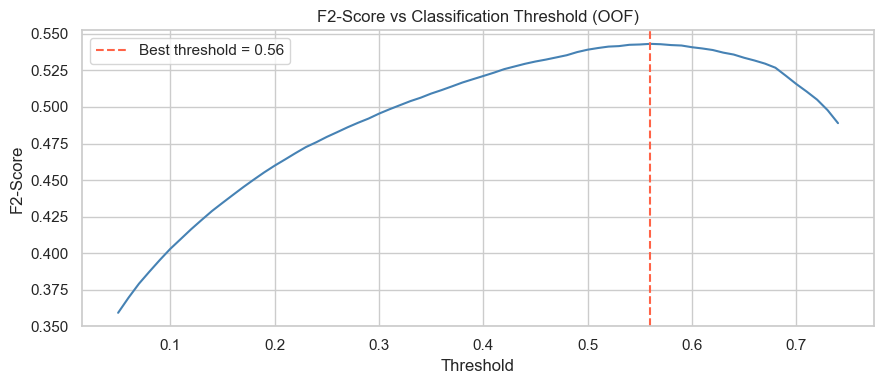

In [13]:
# ── THRESHOLD TUNING FOR F2-SCORE ────────────────────────────────────────────
# Use the best model (class_weight='balanced', no SMOTE) with OOF probabilities

# Out-of-fold probabilities to tune threshold
oof_probs  = np.zeros(len(y_train))
oof_labels = np.zeros(len(y_train))

for tr_idx, val_idx in SKF.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
    m = HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05, max_depth=6,
        class_weight='balanced', random_state=42)
    m.fit(X_tr, y_tr)
    oof_probs[val_idx]  = m.predict_proba(X_val)[:, 1]
    oof_labels[val_idx] = y_val.values

# Search best threshold
thresholds = np.arange(0.05, 0.75, 0.01)
f2_scores  = [fbeta_score(oof_labels, (oof_probs >= t).astype(int), beta=2)
              for t in thresholds]

best_threshold = thresholds[np.argmax(f2_scores)]
best_f2        = max(f2_scores)
print(f"Best threshold: {best_threshold:.2f}  |  OOF F2: {best_f2:.4f}")

plt.figure(figsize=(9, 4))
plt.plot(thresholds, f2_scores, color='steelblue')
plt.axvline(best_threshold, color='tomato', linestyle='--',
            label=f'Best threshold = {best_threshold:.2f}')
plt.title('F2-Score vs Classification Threshold (OOF)')
plt.xlabel('Threshold')
plt.ylabel('F2-Score')
plt.legend()
plt.tight_layout()
plt.show()

## Step 13: OOF Evaluation & Confusion Matrix

Evaluate the model's quality using the **optimized threshold** on out-of-fold predictions:

- **Classification report** — shows Precision, Recall, and F1 separately for `No` and `Yes`. In a healthcare context, the **Recall for `Yes`** (sensitivity) is the most important metric — missing a sick patient is more costly than a false alarm.
- **Confusion matrix** — a 2×2 table showing:
  - **True Negatives (top-left)** — correctly predicted healthy
  - **False Positives (top-right)** — healthy incorrectly flagged
  - **False Negatives (bottom-left)** — sick patients missed ← minimize this
  - **True Positives (bottom-right)** — sick patients correctly identified ← maximize this


=== Classification Report (OOF, best threshold) ===
              precision    recall  f1-score   support

          No       0.98      0.78      0.87    203322
         Yes       0.24      0.78      0.37     18068

    accuracy                           0.78    221390
   macro avg       0.61      0.78      0.62    221390
weighted avg       0.92      0.78      0.83    221390



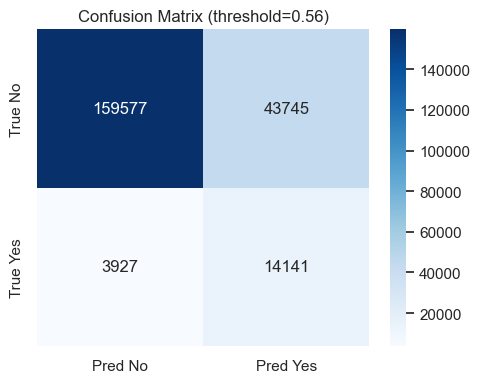

In [14]:
# ── EVALUATION ON OOF PREDICTIONS ────────────────────────────────────────────
oof_preds = (oof_probs >= best_threshold).astype(int)

print("=== Classification Report (OOF, best threshold) ===")
print(classification_report(oof_labels, oof_preds, target_names=['No', 'Yes']))

cm = confusion_matrix(oof_labels, oof_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred No', 'Pred Yes'],
            yticklabels=['True No', 'True Yes'])
plt.title(f'Confusion Matrix (threshold={best_threshold:.2f})')
plt.tight_layout()
plt.show()

## Step 14: Feature Importance (Random Forest)

Train a dedicated `RandomForestClassifier` on the full training data and extract **feature importances** — the average reduction in Gini impurity each feature contributes across all trees.

The horizontal bar chart shows features ranked from least to most important.  
Features at the top of the chart (highest importance) are the ones the model relies on most when deciding whether a patient has heart disease. These typically include `risk_count`, `General Health`, `Diagnosed Diabetes`, `Age`, and `BMI` — confirming that domain knowledge-driven engineering is captured by the model.


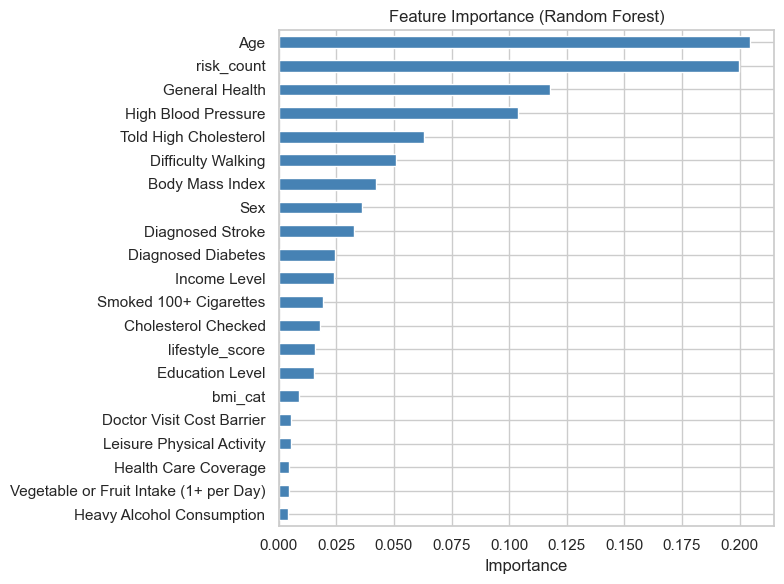

In [16]:
# ── FEATURE IMPORTANCE ───────────────────────────────────────────────────────
rf_importance = RandomForestClassifier(
    n_estimators=200, max_depth=12, class_weight='balanced',
    n_jobs=-1, random_state=42)
rf_importance.fit(X_train, y_train)

feat_imp = pd.Series(rf_importance.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Step 15: Generate Final Submission

Retrain the best model (`HistGradientBoostingClassifier`) on the **entire training dataset** — not just CV folds — to use every available labeled example for the final predictions.

Then:
1. **Predict probabilities** on the test set using `predict_proba()[:, 1]` (probability of class `Yes`)
2. **Apply the optimized threshold** found in Step 12 to convert probabilities to `0/1` labels
3. **Map back to strings** — `1 → 'Yes'`, `0 → 'No'` to match submission format
4. **Save `submission.csv`** with columns `ID` and `History of HeartDisease or Attack`

The predicted positive rate is printed as a sanity check — it should be higher than the naive 0.5 default (due to the lowered threshold), but not unrealistically high.


In [17]:
# ── GENERATE SUBMISSION ───────────────────────────────────────────────────────
# Retrain final model on the entire training set (no SMOTE, class_weight='balanced')
final_model_full = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.05, max_depth=6,
    class_weight='balanced', random_state=42)
final_model_full.fit(X_train, y_train)

# Predict on test set using optimised threshold
test_probs = final_model_full.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= best_threshold).astype(int)
test_labels = np.where(test_preds == 1, 'Yes', 'No')

submission = pd.DataFrame({
    'ID': test['ID'],
    TARGET: test_labels
})

submission_path = os.path.join(DATA_PATH, 'submission.csv')
submission.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"Predicted positive rate: {test_preds.mean():.4f}")
print(f"\nSubmission value counts:\n{submission[TARGET].value_counts()}")
submission.head(10)

Submission saved to: C:\Users\punda\Desktop\superAI\Hackathon 5\Heart Disease Prediction\super-ai-engineer-ss-6-heart-disease-prediction\submission.csv
Predicted positive rate: 0.3039

Submission value counts:
History of HeartDisease or Attack
No     51765
Yes    22596
Name: count, dtype: int64


,ID,History of HeartDisease or Attack
0,test_000001,No
1,test_000002,No
2,test_000003,Yes
3,test_000004,No
4,test_000005,No
5,test_000006,Yes
6,test_000007,Yes
7,test_000008,Yes
8,test_000009,Yes
9,test_000010,No
